In [39]:
from sklearn.datasets import fetch_20newsgroups

cats = ['rec.autos', 'rec.motorcycles', 'rec.sport.baseball']

newsgroups = fetch_20newsgroups(subset='all', categories=cats)
newsgroups.target.shape

(2980,)

In [40]:
newsgroups.data[0]

"From: infante@acpub.duke.edu (Andrew  Infante)\nSubject: Re: Your opinion and what it means to me.\nOrganization: Duke University; Durham, N.C.\nLines: 37\nNntp-Posting-Host: teer1.acpub.duke.edu\n\nIn article <1993Apr20.235735.23007@bnr.ca> MBEAVING@BNR.CA writes:\n>|> \n>|> So, Take you own advice and wuit you whining about\n>|> flames.\n>|> \n>\n>No brains and he can't spell either.\n>\n>.edu?? I hope you're not a student at Duke...\n>you would be wasting your tuition.\n>\n>\n>===================================================\n>= The Beav |Mike Beavington| Dod:9733             =\n>= V65Sabre     mbeaving@bnr.ca                    =\n>= My employer has no idea what I'm talking about! =\n>===================================================\n\nOOOoooh, complaining about my spelling.\n\nI'm _so_ hurt.\n\nNo I'm not a student.  I'm an alumnus.  And an employee.\n\nSo I can get my money _back_ from these grubs.\n\nBNR, huh?  I hope you're not a permanent,\nthey'd be wasting benefits on

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
vectors = vectorizer.fit_transform(newsgroups.data)
vectors.shape

(2980, 31000)

In [42]:
vectors.data[0]

np.float64(0.030724230206317697)

In [43]:
X = vectors
y = newsgroups.target

In [58]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
y_pred = kmeans.fit_predict(X)

In [73]:
from sklearn.metrics import accuracy_score
import itertools

iterator = itertools.permutations([0, 1, 2])
max_acc = 0
order = {}

for x, y, z in iterator:
    cond = {0: x, 1: y, 2: z}
    y_pred_cond = [cond[x] for x in y_pred]

    acc = accuracy_score(newsgroups.target, y_pred_cond)
    if acc > max_acc:
        max_acc = acc
        order = cond

print(f"Точность: {max_acc:.4f}, X= {order[0]} Y= {order[1]} Z= {order[2]}")

Точность: 0.5057, X= 0 Y= 2 Z= 1


In [74]:
from umap import UMAP


umap = UMAP(n_components=2, random_state=42)

X_umap = umap.fit_transform(vectors)

c:\Users\User\Documents\Yandex.Disk\Магистратура\1 курс\2 трим\Кластеризация\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: title={'center': 'Предсказанный'}>

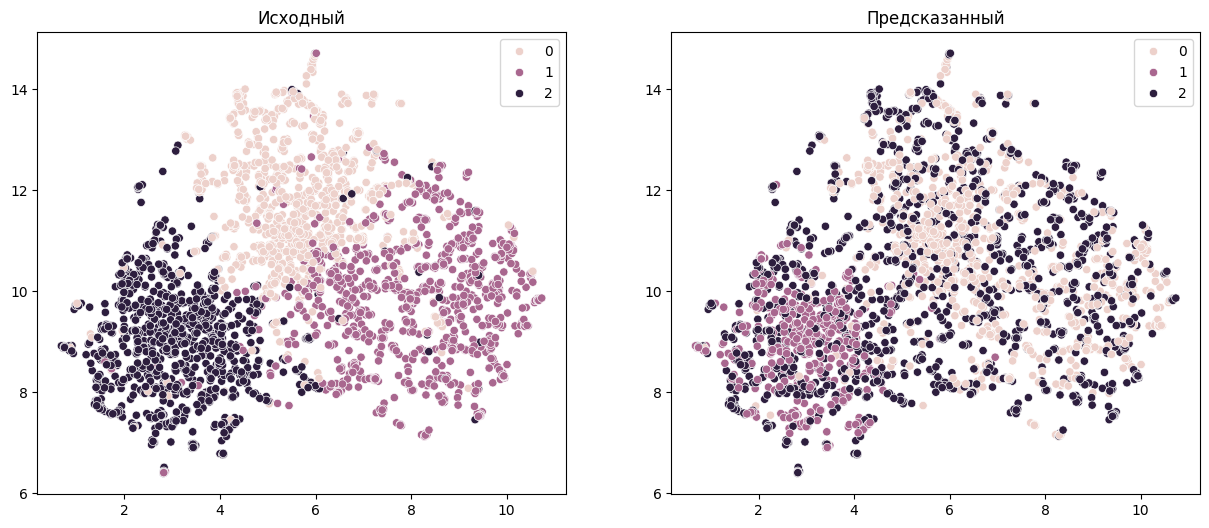

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.subplot(1, 2, 1)
plt.title("Исходный")
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=newsgroups.target)
plt.subplot(1, 2, 2)
plt.title("Предсказанный")
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_pred)

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
import umap.umap_ as umap
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, 
                             davies_bouldin_score, adjusted_rand_score,
                             adjusted_mutual_info_score, homogeneity_completeness_v_measure)
import warnings
warnings.filterwarnings('ignore')
import time

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class DRComparer:
    """Класс для сравнения различных методов уменьшения размерности"""
    
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.dr_methods = {}
        self.dr_results = {}
        
    def apply_pca(self, X, n_components=None, variance_threshold=0.95):
        """Применение PCA"""
        if n_components is None:
            pca = PCA(n_components=variance_threshold, random_state=self.random_state)
        else:
            pca = PCA(n_components=n_components, random_state=self.random_state)
        
        X_pca = pca.fit_transform(X)
        explained_variance = pca.explained_variance_ratio_
        
        self.dr_results['PCA'] = {
            'transformed': X_pca,
            'explained_variance': explained_variance,
            'n_components': X_pca.shape[1],
            'total_variance': explained_variance.sum()
        }
        
        return X_pca, pca
    
    def apply_isomap(self, X, n_components=2, n_neighbors=5):
        """Применение Isomap"""
        isomap = Isomap(n_components=n_components, n_neighbors=n_neighbors)
        X_isomap = isomap.fit_transform(X)
        
        self.dr_results['Isomap'] = {
            'transformed': X_isomap,
            'n_components': n_components,
            'n_neighbors': n_neighbors
        }
        
        return X_isomap, isomap
    
    def apply_tsne(self, X, n_components=2, perplexity=30, learning_rate=200):
        """Применение t-SNE"""
        tsne = TSNE(n_components=n_components, 
                   perplexity=perplexity,
                   learning_rate=learning_rate,
                   init="random",
                   n_jobs=-1)
        
        X_tsne = tsne.fit_transform(X)
        
        self.dr_results['t-SNE'] = {
            'transformed': X_tsne,
            'n_components': n_components,
            'perplexity': perplexity
        }
        
        return X_tsne, tsne
    
    def apply_umap(self, X, n_components=2, n_neighbors=15, min_dist=0.1):
        """Применение UMAP"""
        reducer = umap.UMAP(n_components=n_components,
                          n_neighbors=n_neighbors,
                          min_dist=min_dist,
                          random_state=self.random_state,
                          n_jobs=-1)
        
        X_umap = reducer.fit_transform(X)
        
        self.dr_results['UMAP'] = {
            'transformed': X_umap,
            'n_components': n_components,
            'n_neighbors': n_neighbors,
            'min_dist': min_dist
        }
        
        return X_umap, reducer
    
    def apply_all_methods(self, X, n_components_2d=2):
        """Применение всех методов DR"""
        print("Применение методов уменьшения размерности...")
        print("-" * 50)
        
        results = {}
        
        # PCA (сохраняем 95% дисперсии)
        start = time.time()
        X_pca, pca_model = self.apply_pca(X, n_components=n_components_2d, variance_threshold=0.95)
        pca_time = time.time() - start
        print(f"PCA выполнено за {pca_time:.2f} сек")
        print(f"  Компонент: {X_pca.shape[1]}, Объясненная дисперсия: {self.dr_results['PCA']['total_variance']:.3f}")
        
        # PCA для 2D визуализации
        pca_2d = PCA(n_components=n_components_2d, random_state=self.random_state)
        X_pca_2d = pca_2d.fit_transform(X)
        results['PCA_2D'] = X_pca_2d
        
        # Isomap
        start = time.time()
        X_isomap, isomap_model = self.apply_isomap(X, n_components=n_components_2d)
        isomap_time = time.time() - start
        print(f"Isomap выполнено за {isomap_time:.2f} сек")
        
        # t-SNE
        start = time.time()
        X_tsne, tsne_model = self.apply_tsne(X, n_components=n_components_2d)
        tsne_time = time.time() - start
        print(f"t-SNE выполнено за {tsne_time:.2f} сек")
        
        # UMAP
        start = time.time()
        X_umap, umap_model = self.apply_umap(X, n_components=n_components_2d)
        umap_time = time.time() - start
        print(f"UMAP выполнено за {umap_time:.2f} сек")
        
        # Сохраняем результаты
        results['PCA'] = X_pca
        results['PCA_2D'] = X_pca_2d
        results['Isomap'] = X_isomap
        results['t-SNE'] = X_tsne
        results['UMAP'] = X_umap
        
        # Информация о времени выполнения
        self.execution_times = {
            'PCA': pca_time,
            'Isomap': isomap_time,
            't-SNE': tsne_time,
            'UMAP': umap_time
        }
        
        return results

# Визуализация DR-результатов
def visualize_dr_results(dr_results, y_true):
    """Визуализация результатов различных методов DR"""
    
    methods = ['PCA_2D', 'Isomap', 't-SNE', 'UMAP']
    titles = ['PCA (2D)', 'Isomap', 't-SNE', 'UMAP']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx, (method, title) in enumerate(zip(methods, titles)):
        X_dr = dr_results[method]
        
        scatter = axes[idx].scatter(X_dr[:, 0], X_dr[:, 1], 
                                   c=y_true, cmap='tab10', 
                                   s=40, alpha=0.7, edgecolor='k', linewidth=0.5)
        
        axes[idx].set_title(f'{title}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Component 1')
        axes[idx].set_ylabel('Component 2')
        axes[idx].grid(True, alpha=0.3)
        
        # Добавляем цветовую шкалу для первого графика
        if idx == 0:
            plt.colorbar(scatter, ax=axes[idx], label='True Classes')
    
    plt.suptitle(f'DR Methods Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

Применение методов уменьшения размерности...
--------------------------------------------------
PCA выполнено за 0.04 сек
  Компонент: 3, Объясненная дисперсия: 0.025
Isomap выполнено за 2.65 сек
t-SNE выполнено за 15.05 сек
UMAP выполнено за 3.15 сек

Визуализация результатов DR-методов:


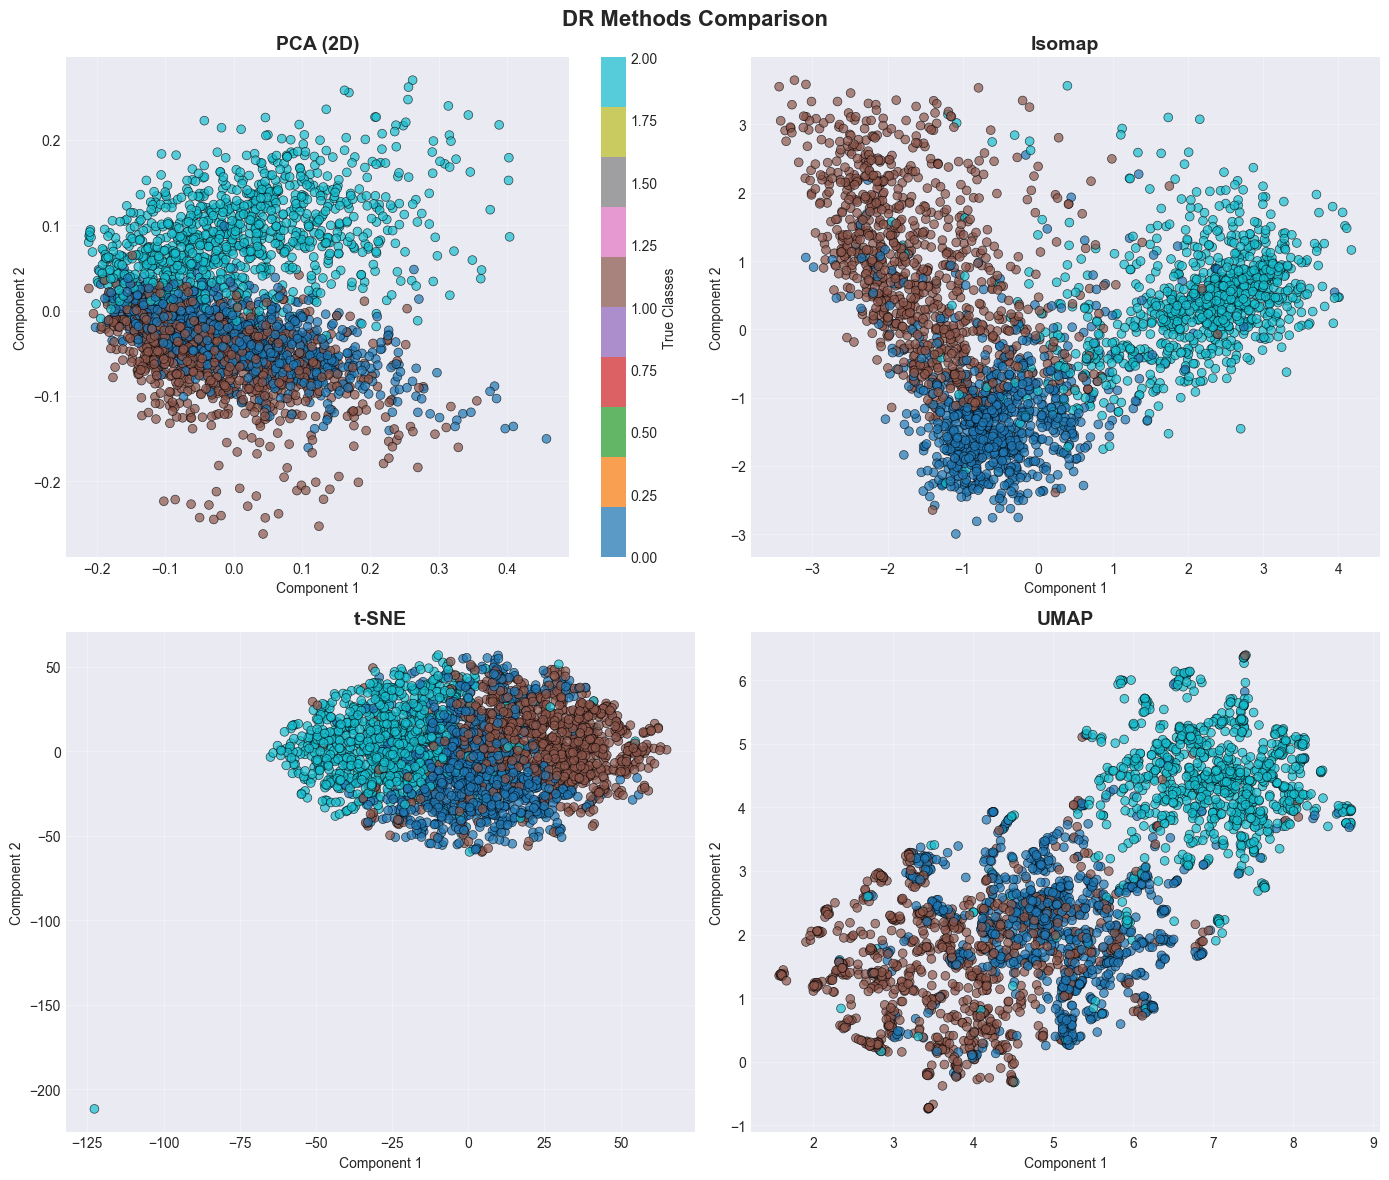

In [90]:
# Загрузка данных
cats = ['rec.autos', 'rec.motorcycles', 'rec.sport.baseball']

newsgroups = fetch_20newsgroups(subset='all', categories=cats)
y = newsgroups.target

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(newsgroups.data)

# Применение методов DR
dr_comparer = DRComparer(random_state=42)
dr_results = dr_comparer.apply_all_methods(X, n_components_2d=3)

# Визуализация
print("\nВизуализация результатов DR-методов:")
visualize_dr_results(dr_results, y)